In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

In [2]:
## Cleaned Data

eco_df = pd.read_csv('../datasets/eco_df_clean.csv')


In [3]:
## Raws that are related to Toxoplasmosis only

tox_keywords = [
    'toxoplasma',
    'toxoplasmosis',
    'toxoplasma gondii'
]

df_toxo_eco = eco_df[
    eco_df['Details']
    .str.lower()
    .str.contains('|'.join(tox_keywords), na=False)
]



## CATS only

cats_only_df = eco_df[
    eco_df['Common_name']
    .astype(str)
    .str.lower()
    .str.contains(r'\bcat\b', na=False) &
    ~eco_df['Common_name'].str.contains(r',|\+|/|;|\band\b', case=False, na=False)
]


## Subset with multispecies
multi_species_df_eco = eco_df[
    eco_df['Common_name']
    .str.lower()
    .str.contains('cat', na=False) &
    eco_df['Common_name']
    .str.contains(',|\+| and |;', na=False)
]


## Cats VS. Cats and someone else

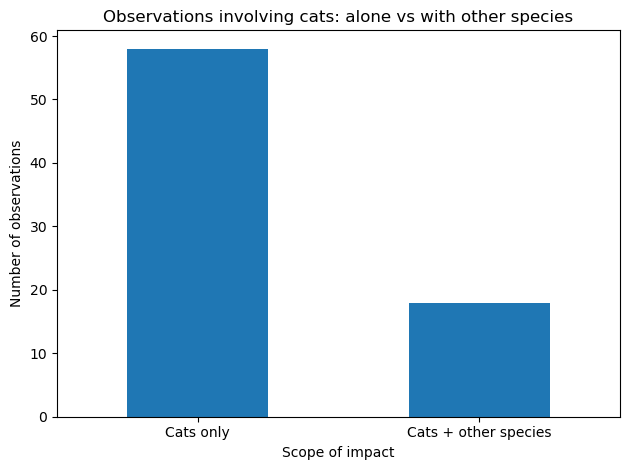

In [4]:
##  Create scope variable
eco_df['cat_scope'] = eco_df['Common_name'].apply(
    lambda x: 'Cats only'
    if isinstance(x, str) and ',' not in x
    else 'Cats + other species'
)

## Count observations
cat_counts = eco_df['cat_scope'].value_counts()

## Plot
plt.figure()
cat_counts.plot(kind='bar')
plt.title('Observations involving cats: alone vs with other species')
plt.xlabel('Scope of impact')
plt.ylabel('Number of observations')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Types of Cost

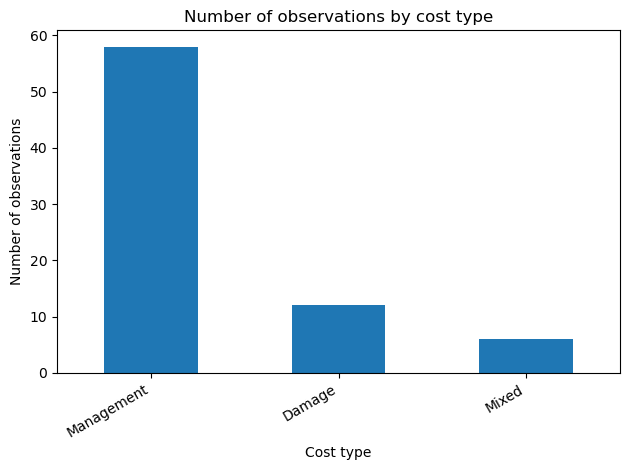

In [5]:
type_counts = eco_df['Type_of_cost_merged'].value_counts()

plt.figure()
type_counts.plot(kind='bar')
plt.title('Number of observations by cost type')
plt.xlabel('Cost type')
plt.ylabel('Number of observations')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## Cost Type: Cats VS. Cats + others...

In [9]:
eco_df.dtypes

Species                                           object
Common_name                                       object
Environment                                       object
urbanArea                                         object
Island                                            object
Official_country                                  object
State|Province|Administrative_area                object
Location                                          object
Time_range                                        object
Probable_starting_year                            object
Probable_ending_year                              object
Cost_estimate_per_year_2017_USD_exchange_rate    float64
Cost_estimate_per_year_2017_USD_PPP              float64
Currency                                          object
Applicable_year                                    int64
Impacted_sector                                   object
Type_of_cost                                      object
Type_of_cost_merged            

In [10]:
cols_to_corr = ['Cost_estimate_per_year_2017_USD_exchange_rate', 'Cost_estimate_per_year_2017_USD_PPP']
numerical_eco = eco_df[cols_to_corr]

# 2. Generate the correlation matrix
corr = numerical_eco.corr()

# 3. Display with the heat gradient
corr.style.background_gradient(cmap='coolwarm', axis=None).format(precision=2)

,Cost_estimate_per_year_2017_USD_exchange_rate,Cost_estimate_per_year_2017_USD_PPP
Cost_estimate_per_year_2017_USD_exchange_rate,1.00,1.00
Cost_estimate_per_year_2017_USD_PPP,1.00,1.00
